# Backpropagation for Feedforward Networks
**Course:** Artificial Neural Networks (20.IDI23) · **Mentor:** Prof. Branimir Todorović · **Author:** Elvir Muslić

This notebook accompanies the seminar paper *Backpropagation for Feedforward Networks*. It has three parts.

1. **The worked step (Section 4 of the paper).** The forward pass, the loss and the backward recursion (5)–(7) are computed by hand for the smallest network, then compared with PyTorch's automatic differentiation and with central finite differences (4).
2. **Training with PyTorch.** The networks are built from `torch.nn` layers; `loss.backward()` computes the gradient by automatic differentiation, which carries out the backward recursion, and `torch.optim.SGD` applies the gradient-descent update (3).
3. **Two experiments (Section 5).** XOR, and the two moons of scikit-learn.

Run it in VS Code with the `.venv` kernel (Run All), or from this folder with `.venv/bin/jupyter nbconvert --to notebook --execute --inplace backprop_project.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons
from torch import nn

torch.set_default_dtype(torch.float64)   # double precision, so that the gradient comparisons below are meaningful
Path("figures").mkdir(exist_ok=True)

## 1. The worked step by hand (Section 4)
One input $x = 1$, one hidden unit and one output unit, both logistic, weights $W^{(1)} = W^{(2)} = 0.5$, zero biases, target $y = 1$. The lines follow the paper: the forward pass (1) and the loss (2), then the backward recursion from the output back to the first weight: the output sensitivity (5), the weight gradient (7), the sensitivity one layer back (6), and again (7). The printed values are Table 1 of the paper.

In [2]:
x, y, W1, W2 = torch.tensor(1.0), torch.tensor(1.0), torch.tensor(0.5), torch.tensor(0.5)   # zero biases
a1 = W1 * x                                   # forward pass (1)
h1 = torch.sigmoid(a1)
a2 = W2 * h1
y_hat = torch.sigmoid(a2)
E = 0.5 * (y_hat - y) ** 2                    # loss (2)
delta2 = (y_hat - y) * y_hat * (1 - y_hat)    # (5)
dE_dW2 = delta2 * h1                          # (7)
delta1 = delta2 * W2 * h1 * (1 - h1)          # (6)
dE_dW1 = delta1 * x                           # (7)
for name, value in dict(a1=a1, h1=h1, a2=a2, y_hat=y_hat, E=E, delta2=delta2, dE_dW2=dE_dW2, delta1=delta1, dE_dW1=dE_dW1).items():
    print(f"{name:>7} = {value:12.9f}")

     a1 =  0.500000000
     h1 =  0.622459331
     a2 =  0.311229666
  y_hat =  0.577185380
      E =  0.089386101
 delta2 = -0.103184702
 dE_dW2 = -0.064228280
 delta1 = -0.012124394
 dE_dW1 = -0.012124394


**The same gradient in two other ways, and one training step.** Automatic differentiation: PyTorch records the operations of the forward pass, and `backward()` applies the chain rule to them in reverse order, which is the backward recursion. Central differences (4): change one weight by $\pm\epsilon$ and divide the change of the loss by $2\epsilon$; no derivation is needed, but each weight costs two forward passes. Last, one gradient-descent step (3) with $\eta = 1$.

In [3]:
def loss_at(w1, w2):                                  # the loss of the small network as a function of its two weights
    return 0.5 * (torch.sigmoid(w2 * torch.sigmoid(w1 * x)) - y) ** 2

hand = torch.stack([dE_dW1, dE_dW2])
w = torch.tensor([0.5, 0.5], requires_grad=True)      # the same two weights, now recorded by autograd
loss_at(w[0], w[1]).backward()                        # backpropagation by automatic differentiation
print(f"autograd: {w.grad.tolist()}, largest difference from the hand values {(w.grad - hand).abs().max():.1e}")

eps = 1e-6                                            # central differences (4)
fd = torch.stack([loss_at(0.5 + eps, 0.5) - loss_at(0.5 - eps, 0.5), loss_at(0.5, 0.5 + eps) - loss_at(0.5, 0.5 - eps)]) / (2 * eps)
print(f"central differences: {fd.tolist()}, differences from the hand values {(fd - hand)[0].abs():.1e} and {(fd - hand)[1].abs():.1e}")

W1_new, W2_new = W1 - 1.0 * dE_dW1, W2 - 1.0 * dE_dW2   # one gradient-descent step (3) with eta = 1
print(f"after one step: W1 = {W1_new:.6f}, W2 = {W2_new:.6f}, y_hat = {torch.sigmoid(W2_new * torch.sigmoid(W1_new * x)):.6f}, "
      f"E falls from {E:.6f} to {loss_at(W1_new, W2_new):.6f}")

autograd: [-0.01212439398403536, -0.06422828047972627], largest difference from the hand values 1.4e-17
central differences: [-0.01212439398184939, -0.06422828045110629], differences from the hand values 2.2e-12 and 2.9e-11
after one step: W1 = 0.512124, W2 = 0.564228, y_hat = 0.587300, E falls from 0.089386 to 0.085161


## 2. Training with PyTorch
A network is an `nn.Sequential` of layers. `nn.Linear(n_in, n_out)` computes $a = Wh + b$ and holds $W$ and $b$ as its parameters; `nn.Tanh()` and `nn.Sigmoid()` apply the activation; so `model(X)` is the forward pass (1). The data hold one example per row, as PyTorch expects. One training step:

- `loss = 0.5 * ((model(X) - Y) ** 2).mean()` is the loss (2), the mean over the examples (the networks have one output unit);
- `optimizer.zero_grad()` clears the gradients of the previous step, because `backward()` adds to them;
- `loss.backward()` computes the gradient with respect to every weight and bias by automatic differentiation, which carries out the backward recursion (5)–(7);
- `optimizer.step()` applies the update (3) to every parameter, $W \leftarrow W - \eta\, \partial E/\partial W$.

In [4]:
def train(model, X, Y, eta, steps):
    # full-batch gradient descent; returns the loss before every step and after the last one
    optimizer = torch.optim.SGD(model.parameters(), lr=eta)
    losses = []
    for _ in range(steps):
        loss = 0.5 * ((model(X) - Y) ** 2).mean()     # loss (2)
        losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()                                # backpropagation (5)-(7), by automatic differentiation
        optimizer.step()                               # update (3)
    losses.append(0.5 * ((model(X) - Y) ** 2).mean().item())
    return losses

def accuracy(model, X, Y):
    # the share of examples whose output, thresholded at 0.5, equals the label
    return ((model(X) > 0.5) == (Y > 0.5)).double().mean().item()

## 3. XOR
The four inputs and their targets. A 2-4-1 network with $\tanh$ hidden units and a logistic output, PyTorch's default random initial weights (seed 0), $\eta = 1$, 2000 steps.

In [5]:
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])   # one example per row
Y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])
torch.manual_seed(0)
xor_net = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 1), nn.Sigmoid())
xor_losses = train(xor_net, X_xor, Y_xor, eta=1.0, steps=2000)
print(f"loss {xor_losses[0]:.4f} -> {xor_losses[-1]:.2e}, outputs {[round(v, 2) for v in xor_net(X_xor).flatten().tolist()]}, "
      f"accuracy {accuracy(xor_net, X_xor, Y_xor):.2f}")

loss 0.1261 -> 4.62e-04, outputs [0.03, 0.98, 0.97, 0.04], accuracy 1.00


## 4. Two moons
Two interleaved half circles with Gaussian noise of standard deviation 0.1, from scikit-learn's `make_moons`: 200 training points and 200 test points, drawn with two different seeds. A 2-16-1 network (seed 0) is trained on the training points with $\eta = 1$ for 5000 steps; the test points only measure the accuracy on new data.

In [6]:
def moons(n, seed):
    X, labels = make_moons(n_samples=n, noise=0.1, random_state=seed)
    return torch.tensor(X), torch.tensor(labels, dtype=torch.float64)[:, None]

X_train, Y_train = moons(200, seed=0)
X_test, Y_test = moons(200, seed=1)
torch.manual_seed(0)
moon_net = nn.Sequential(nn.Linear(2, 16), nn.Tanh(), nn.Linear(16, 1), nn.Sigmoid())
moon_losses = train(moon_net, X_train, Y_train, eta=1.0, steps=5000)
print(f"loss {moon_losses[0]:.4f} -> {moon_losses[-1]:.4f}, training accuracy {accuracy(moon_net, X_train, Y_train):.3f}, "
      f"test accuracy {accuracy(moon_net, X_test, Y_test):.3f}")

loss 0.1241 -> 0.0017, training accuracy 1.000, test accuracy 1.000


## 5. Figures
Figure 1 of the paper shows the training loss per step; Figure 2 shows the two moons and the decision boundary, the curve on which the output equals 0.5.

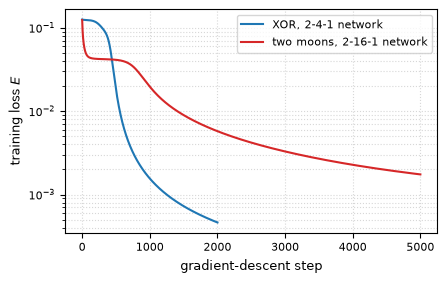

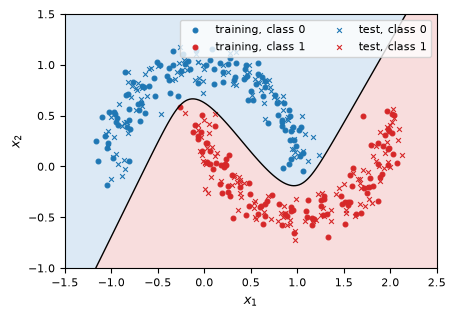

In [7]:
plt.rcParams.update({"font.size": 9, "axes.labelsize": 9, "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8, "pdf.fonttype": 42})
fig, ax = plt.subplots(figsize=(4.8, 2.9))
ax.semilogy(xor_losses, color="tab:blue", label="XOR, 2-4-1 network")
ax.semilogy(moon_losses, color="tab:red", label="two moons, 2-16-1 network")
ax.set(xlabel="gradient-descent step", ylabel="training loss $E$")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.savefig("figures/training_loss.pdf", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(4.8, 3.3))
g1, g2 = torch.meshgrid(torch.linspace(-1.5, 2.5, 201), torch.linspace(-1.0, 1.5, 201), indexing="xy")
with torch.no_grad():
    Z = moon_net(torch.stack([g1.flatten(), g2.flatten()], dim=1)).reshape(g1.shape)
ax.contourf(g1, g2, Z, levels=[0.0, 0.5, 1.0], colors=["#dce9f5", "#f8dddd"])
ax.contour(g1, g2, Z, levels=[0.5], colors="k", linewidths=1.0)
for X_, Y_, marker, name in ((X_train, Y_train, "o", "training"), (X_test, Y_test, "x", "test")):
    for cls, color in ((0, "tab:blue"), (1, "tab:red")):
        ax.scatter(*X_[Y_[:, 0] == cls].T, marker=marker, s=12, color=color, linewidths=0.8, label=f"{name}, class {cls}")
ax.set(xlabel="$x_1$", ylabel="$x_2$")
ax.legend(loc="upper right", ncol=2)
fig.savefig("figures/moons_boundary.pdf", bbox_inches="tight")